
Memproses: terang.jpeg

matriks 3x3 Grayscale (asli):
[[254 254 254]
 [254 254 254]
 [254 254 254]]

matriks 3x3 Grayscale setelah kuantisasi uniform:
[[240 240 240]
 [240 240 240]
 [240 240 240]]

matriks 3x3 Grayscale setelah kuantisasi K-Means:
[[99 93 93]
 [99 93 86]
 [93 93 86]]
Memori awal: 3694080 bytes
Memori setelah kuantisasi Gray: 1231360 bytes
Rasio kompresi: 3.0
Waktu konversi Gray: 0.0006
Waktu konversi HSV: 0.0014
Waktu konversi LAB: 0.0029


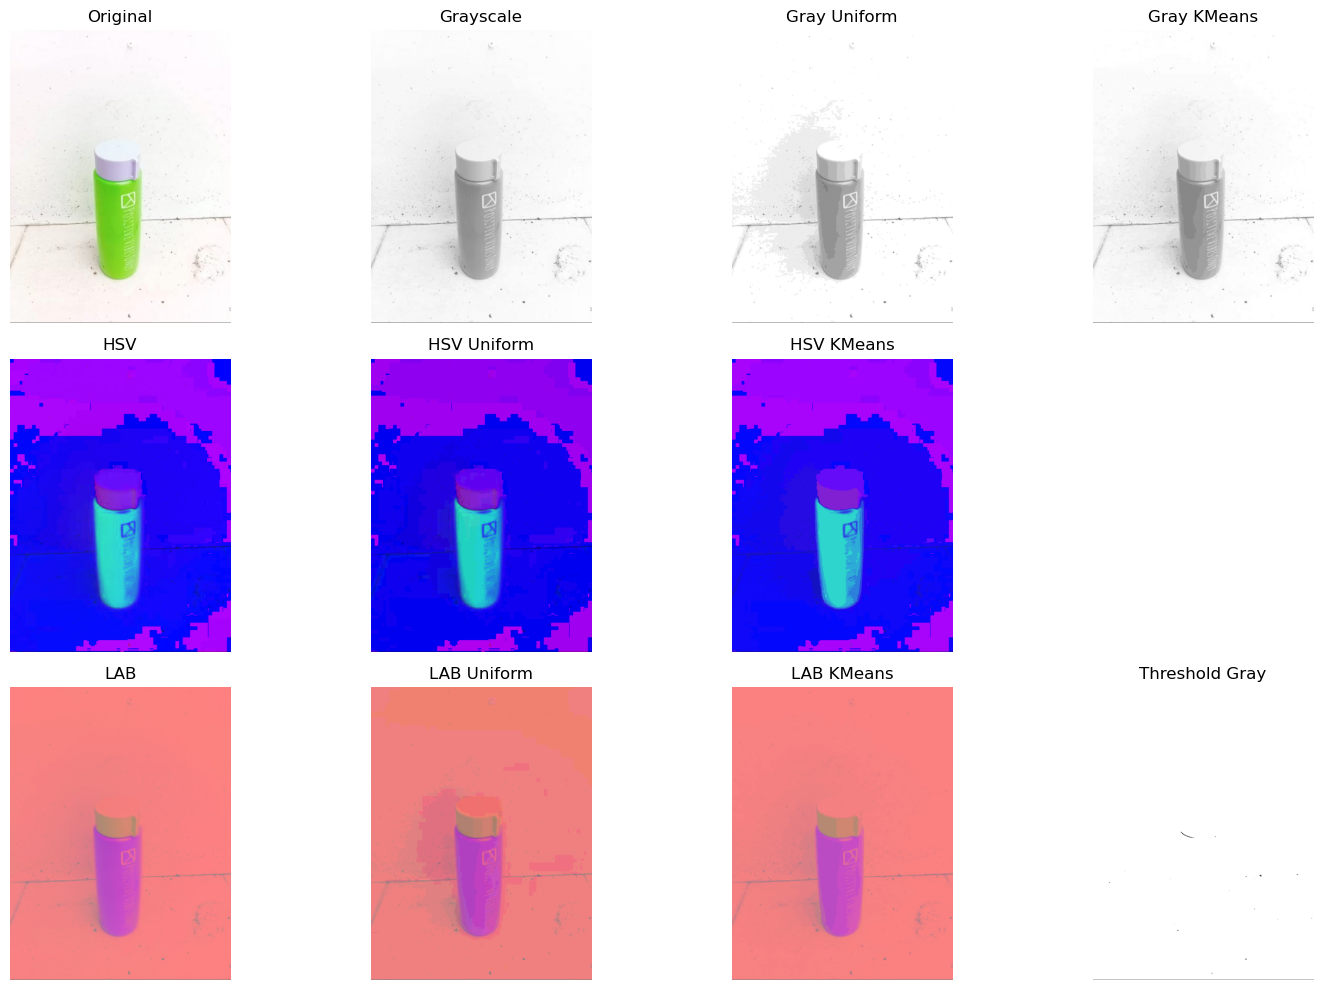

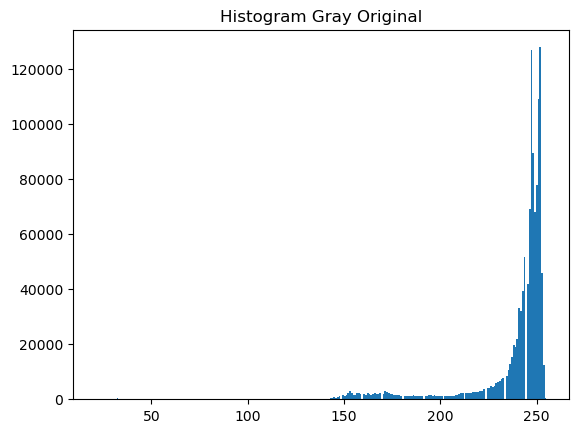

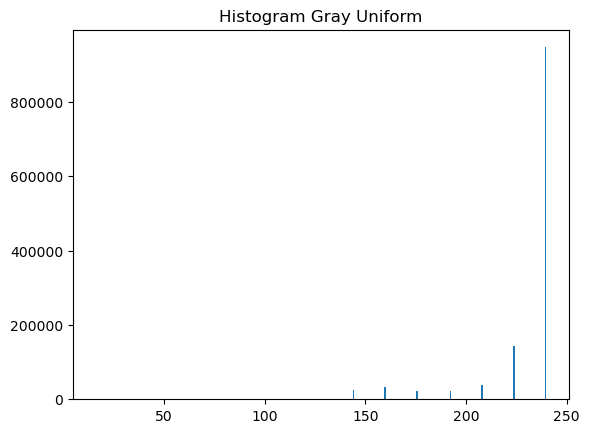

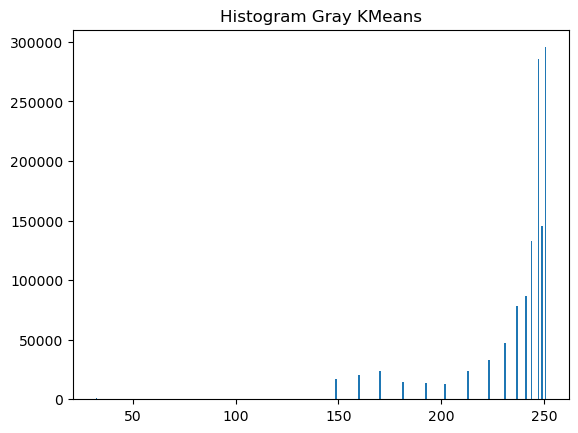

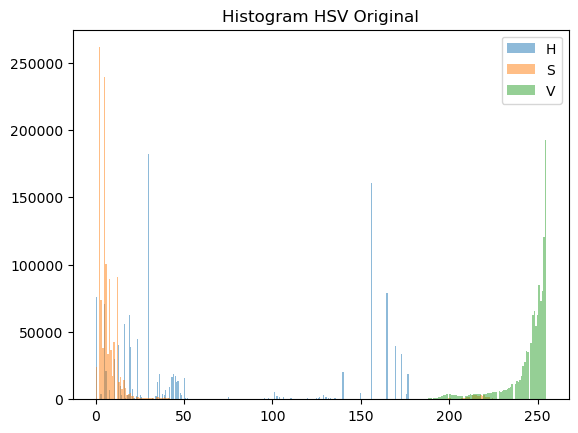

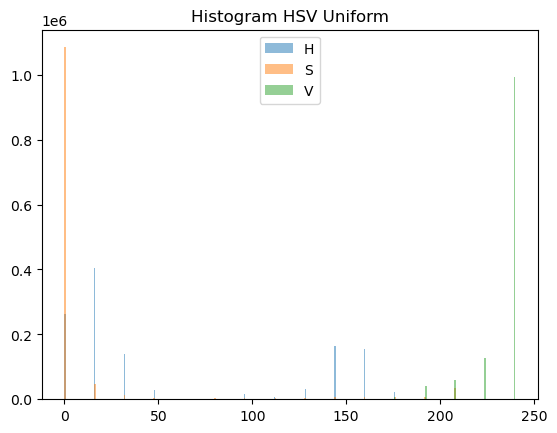

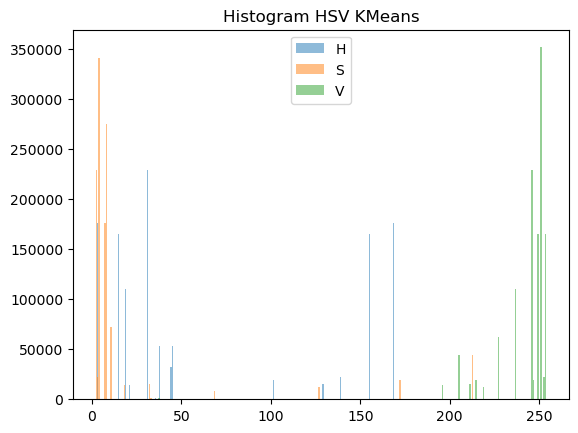

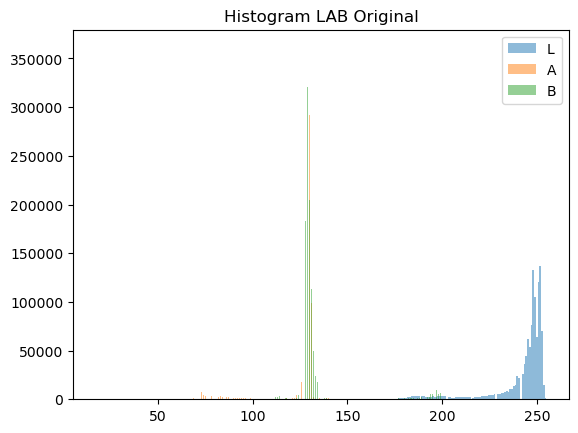

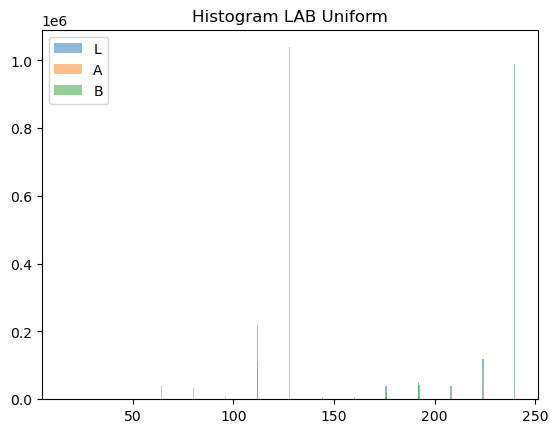

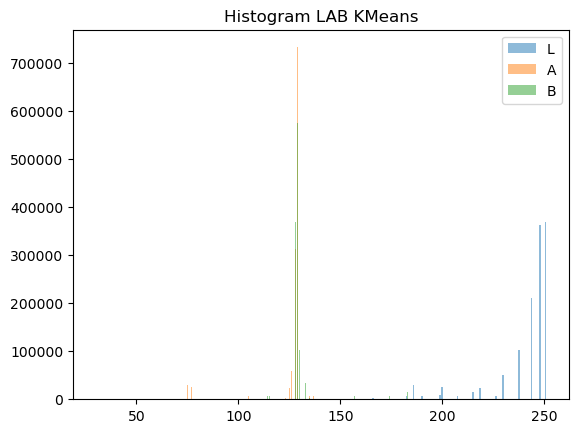


Memproses: normal.jpeg

matriks 3x3 Grayscale (asli):
[[234 234 233]
 [233 232 232]
 [228 228 228]]

matriks 3x3 Grayscale setelah kuantisasi uniform:
[[224 224 224]
 [224 224 224]
 [224 224 224]]

matriks 3x3 Grayscale setelah kuantisasi K-Means:
[[251 251 251]
 [251 251 251]
 [251 251 251]]
Memori awal: 3686400 bytes
Memori setelah kuantisasi Gray: 1228800 bytes
Rasio kompresi: 3.0
Waktu konversi Gray: 0.0009
Waktu konversi HSV: 0.0025
Waktu konversi LAB: 0.0032


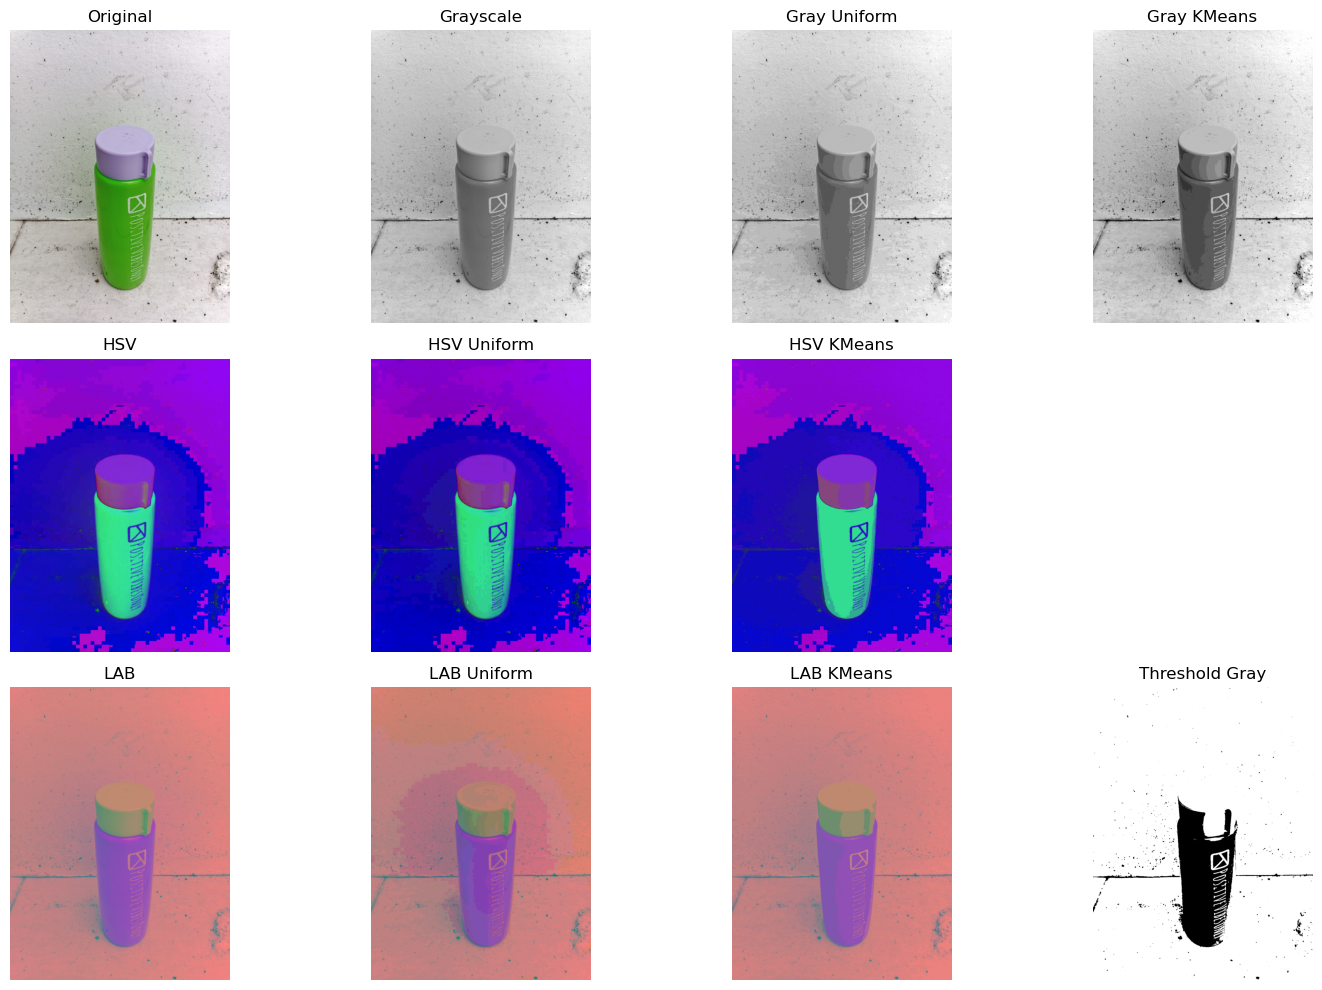

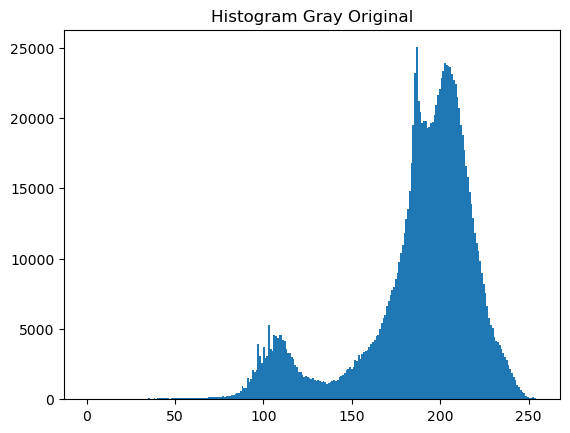

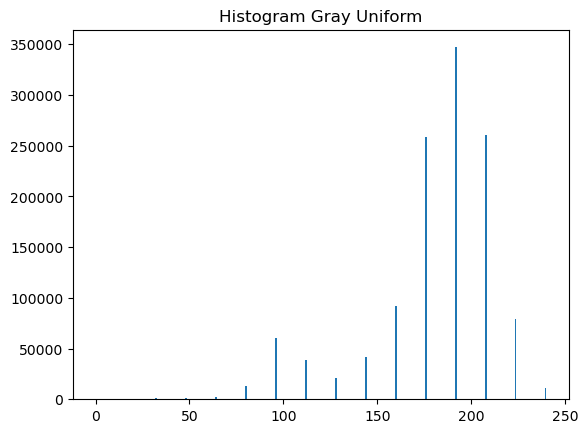

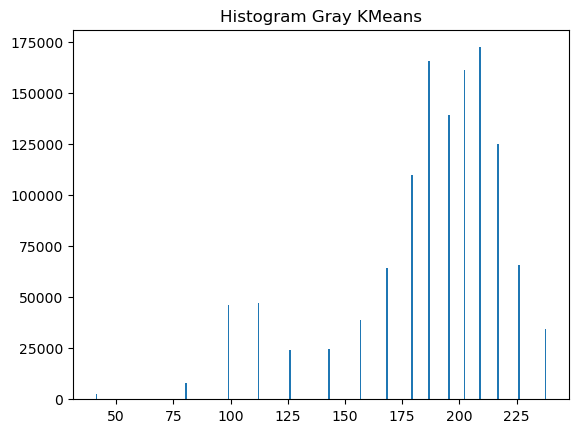

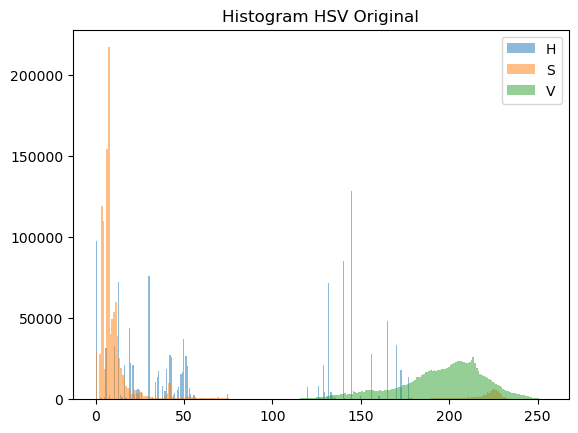

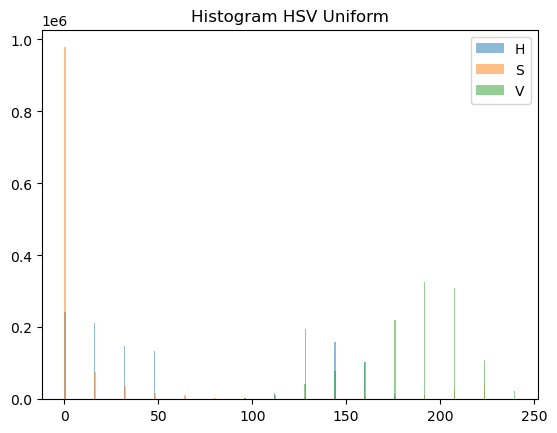

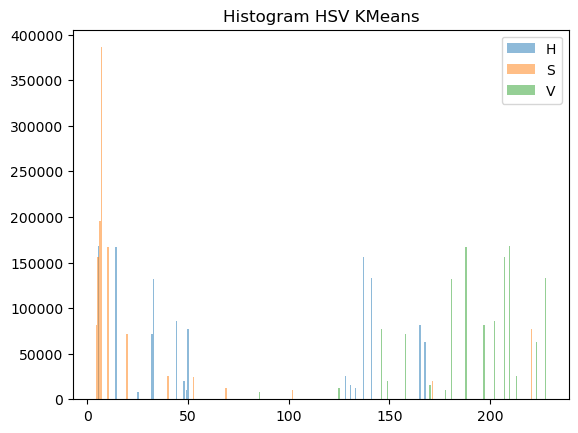

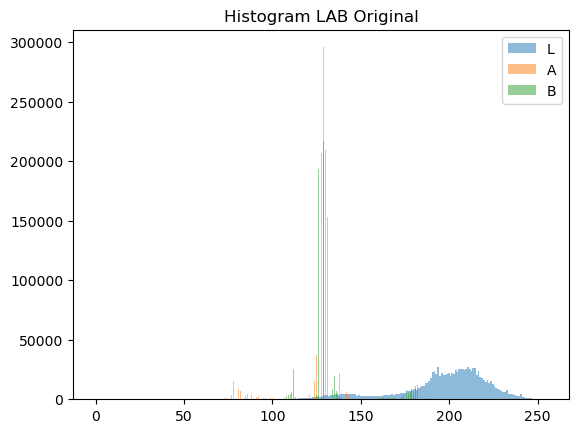

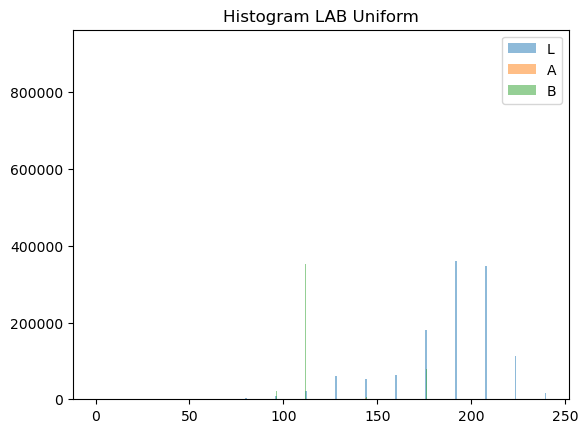

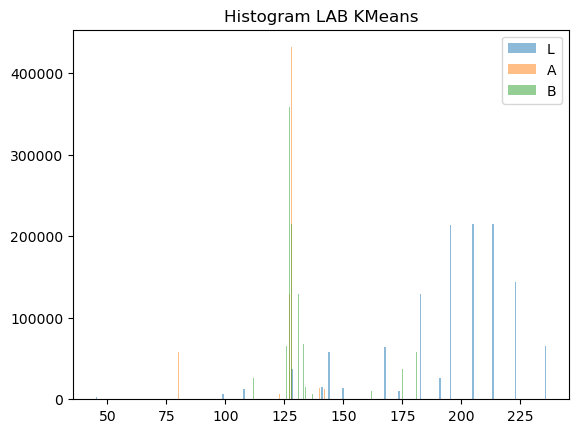


Memproses: redup.jpeg

matriks 3x3 Grayscale (asli):
[[99 95 92]
 [97 94 90]
 [94 93 90]]

matriks 3x3 Grayscale setelah kuantisasi uniform:
[[96 80 80]
 [96 80 80]
 [80 80 80]]

matriks 3x3 Grayscale setelah kuantisasi K-Means:
[[238 238 238]
 [238 226 226]
 [226 226 226]]
Memori awal: 3686400 bytes
Memori setelah kuantisasi Gray: 1228800 bytes
Rasio kompresi: 3.0
Waktu konversi Gray: 0.0006
Waktu konversi HSV: 0.0016
Waktu konversi LAB: 0.0024


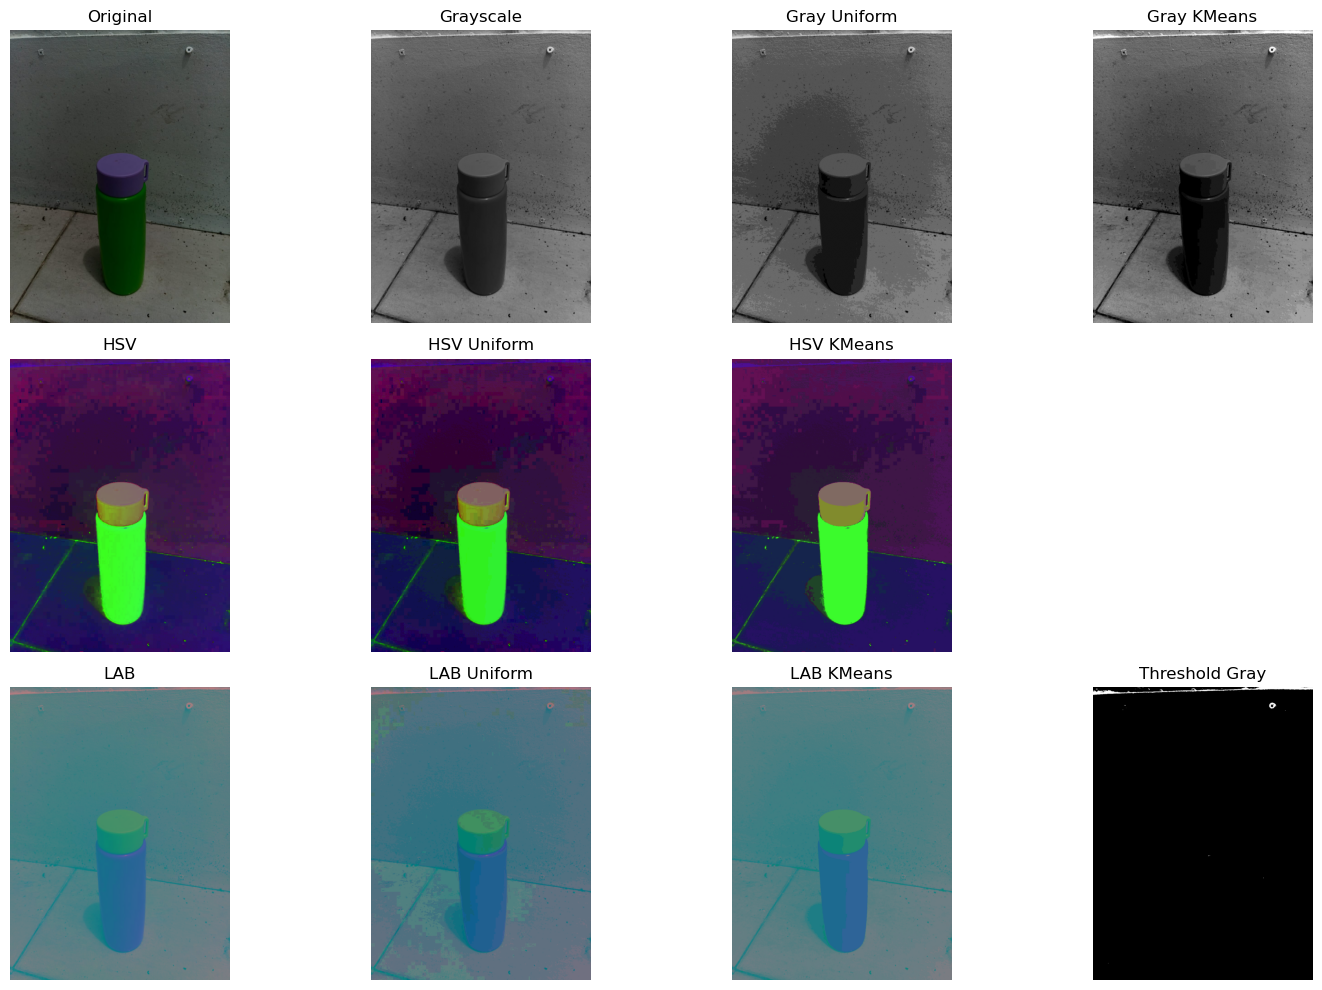

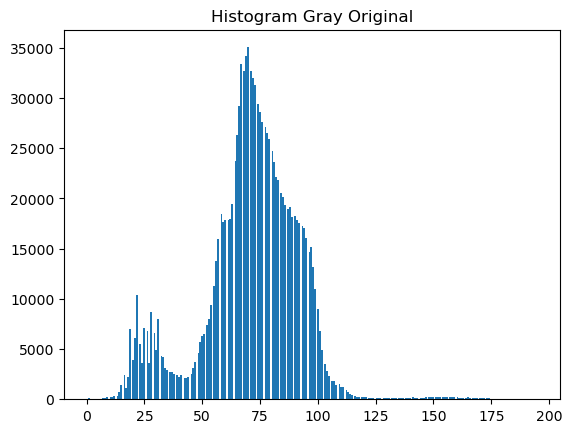

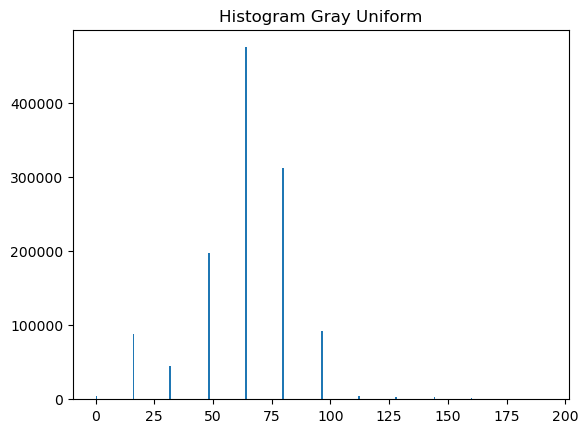

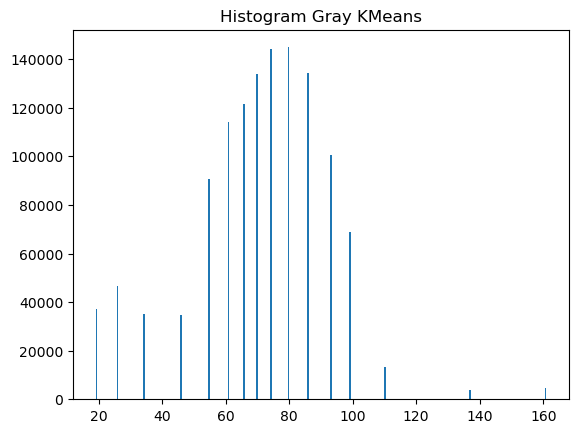

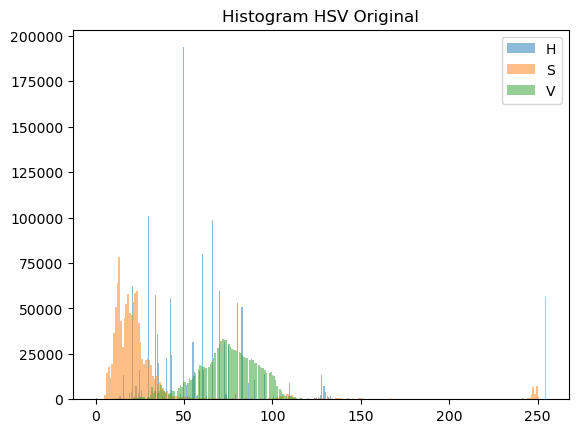

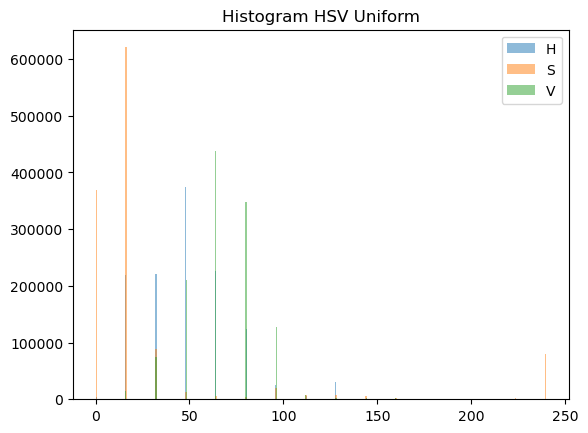

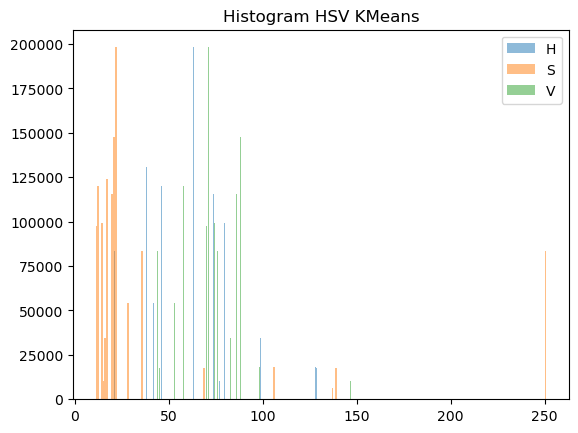

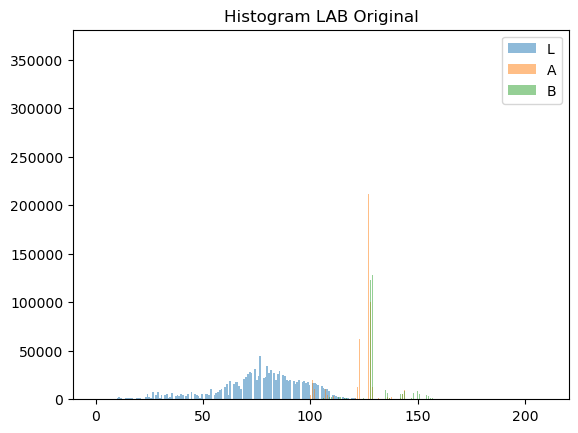

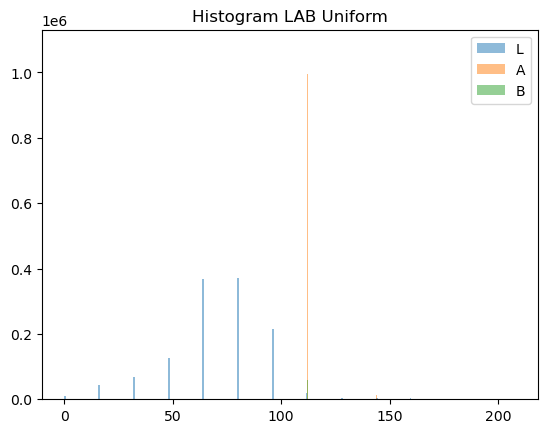

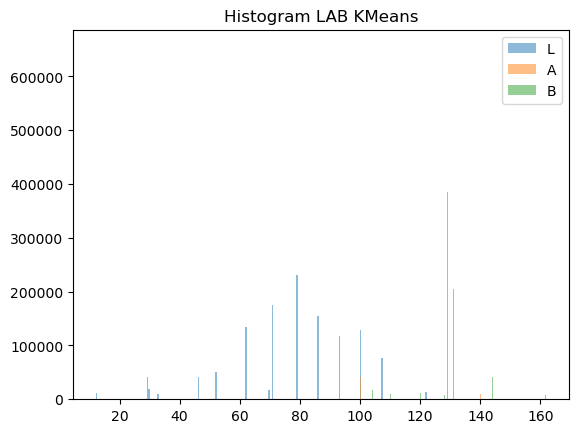


SELESAI SEMUA GAMBAR DIPROSES


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
import os

# ==========================
# FUNGSI KUANTISASI UNIFORM
# ==========================
def kuantisasi_uniform(image, level=16):
    faktor = 256 // level
    return (image // faktor) * faktor

# ==========================
# FUNGSI KUANTISASI KMEANS
# ==========================
def kuantisasi_kmeans(image, k=16):
    shape = image.shape
    # aman untuk grayscale dan color
    data = image.reshape((-1, 1)) if len(shape) == 2 else image.reshape((-1, shape[-1]))
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(data)
    clustered = kmeans.cluster_centers_[kmeans.labels_]
    clustered = clustered.reshape(shape)
    return np.uint8(clustered)

# ==========================
# FUNGSI HISTOGRAM
# ==========================
def plot_histogram(image, title, model='Gray'):
    plt.figure()
    if len(image.shape) == 2:
        plt.hist(image.ravel(), bins=256)
    else:
        channels = ['C1','C2','C3']
        if model=='HSV':
            channels = ['H','S','V']
        elif model=='LAB':
            channels = ['L','A','B']
        for i, ch in enumerate(channels):
            plt.hist(image[:,:,i].ravel(), bins=256, alpha=0.5, label=ch)
        plt.legend()
    plt.title(title)
    plt.show()

# ==========================
# LOAD GAMBAR
# ==========================
gambar_list = ["terang.jpeg", "normal.jpeg", "redup.jpeg"]

for nama_file in gambar_list:
    print("\n======================================")
    print("Memproses:", nama_file)
    print("======================================")
    
    # cek file ada atau tidak
    if not os.path.exists(nama_file):
        print("File tidak ditemukan:", nama_file)
        continue
    
    img = cv2.imread(nama_file)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    memori_awal = img.nbytes

    # ==========================
    # KONVERSI WARNA
    # ==========================
    start = time.time()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    waktu_gray = time.time() - start

    start = time.time()
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    waktu_hsv = time.time() - start

    start = time.time()
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    waktu_lab = time.time() - start

    # ==========================
    # KUANTISASI UNIFORM
    # ==========================
    gray_u = kuantisasi_uniform(gray)
    hsv_u = kuantisasi_uniform(hsv)
    lab_u = kuantisasi_uniform(lab)
   
    # ==========================
    # TAMPILKAN MATRIKS / VEKTOR SEDERHANA
    # ==========================
    
    print("\nmatriks 3x3 Grayscale (asli):")
    print(gray[0:3, 0:3])
    
    print("\nmatriks 3x3 Grayscale setelah kuantisasi uniform:")
    print(gray_u[0:3, 0:3])
    
    print("\nmatriks 3x3 Grayscale setelah kuantisasi K-Means:")
    print(gray_k[0:3, 0:3])
    
    # ==========================
    # KUANTISASI NON UNIFORM (KMEANS)
    # ==========================
    gray_k = kuantisasi_kmeans(gray, 16)
    hsv_k = kuantisasi_kmeans(hsv, 16)
    lab_k = kuantisasi_kmeans(lab, 16)

    # ==========================
    # HITUNG MEMORI & RASIO
    # ==========================
    memori_gray = gray_u.nbytes
    rasio_kompresi = memori_awal / memori_gray

    print("Memori awal:", memori_awal, "bytes")
    print("Memori setelah kuantisasi Gray:", memori_gray, "bytes")
    print("Rasio kompresi:", round(rasio_kompresi,2))
    print("Waktu konversi Gray:", round(waktu_gray,4))
    print("Waktu konversi HSV:", round(waktu_hsv,4))
    print("Waktu konversi LAB:", round(waktu_lab,4))

    # ==========================
    # SEGMENTASI SEDERHANA
    # ==========================
    _, thresh = cv2.threshold(gray_u, 127, 255, cv2.THRESH_BINARY)

    # ==========================
    # VISUALISASI
    # ==========================
    plt.figure(figsize=(15,10))
    plt.subplot(3,4,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,4,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    plt.subplot(3,4,3)
    plt.imshow(gray_u, cmap='gray')
    plt.title("Gray Uniform")
    plt.axis('off')

    plt.subplot(3,4,4)
    plt.imshow(gray_k, cmap='gray')
    plt.title("Gray KMeans")
    plt.axis('off')

    plt.subplot(3,4,5)
    plt.imshow(hsv, cmap='hsv')
    plt.title("HSV")
    plt.axis('off')

    plt.subplot(3,4,6)
    plt.imshow(hsv_u, cmap='hsv')
    plt.title("HSV Uniform")
    plt.axis('off')

    plt.subplot(3,4,7)
    plt.imshow(hsv_k, cmap='hsv')
    plt.title("HSV KMeans")
    plt.axis('off')

    plt.subplot(3,4,9)
    plt.imshow(lab, cmap='nipy_spectral')
    plt.title("LAB")
    plt.axis('off')

    plt.subplot(3,4,10)
    plt.imshow(lab_u, cmap='nipy_spectral')
    plt.title("LAB Uniform")
    plt.axis('off')

    plt.subplot(3,4,11)
    plt.imshow(lab_k, cmap='nipy_spectral')
    plt.title("LAB KMeans")
    plt.axis('off')

    plt.subplot(3,4,12)
    plt.imshow(thresh, cmap='gray')
    plt.title("Threshold Gray")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # ==========================
    # HISTOGRAM
    # ==========================
    plot_histogram(gray, "Histogram Gray Original", model='Gray')
    plot_histogram(gray_u, "Histogram Gray Uniform", model='Gray')
    plot_histogram(gray_k, "Histogram Gray KMeans", model='Gray')

    plot_histogram(hsv, "Histogram HSV Original", model='HSV')
    plot_histogram(hsv_u, "Histogram HSV Uniform", model='HSV')
    plot_histogram(hsv_k, "Histogram HSV KMeans", model='HSV')

    plot_histogram(lab, "Histogram LAB Original", model='LAB')
    plot_histogram(lab_u, "Histogram LAB Uniform", model='LAB')
    plot_histogram(lab_k, "Histogram LAB KMeans", model='LAB')

print("\nSELESAI SEMUA GAMBAR DIPROSES")